# 02 — Customers EDA
## Customer Profiles & Behavioral Analysis

**Purpose.** Deep exploratory analysis of the customer profile data
(`customers.csv`) and the behavioral signals derived by joining with the
transactions file. **This is the primary preparation for Module 4 — Customer
Segmentation.**

**What this notebook covers:**
- Schema and structure of the customers file
- Customer archetype distribution (frequency profiles)
- Behavioral dimensions: price tier, time preference, day preference, basket bias
- **RFM analysis** (Recency, Frequency, Monetary) — the foundation of segmentation
- **Pareto check** — do top customers drive most revenue?
- Joint behavioral diversity across dimensions
- Implications for clustering algorithms (K-Means, DBSCAN)

**Other notebooks in this series:**
- `01_transactions_eda.ipynb` — main transactions
- `03_anomalies_eda.ipynb` — anomaly labels & fraud signals
- `04_cashiers_eda.ipynb` — staff roster

---

## Notebook structure
1. Setup and data loading
2. Customer file schema
3. Archetype and dimension distributions
4. RFM analysis
5. Pareto and revenue concentration
6. Behavioral separation by dimension
7. Summary


## 1. Setup and data loading

We need both `customers.csv` (the profiles) and `enterprise_pos_dataset.csv`
(the transactions) to compute behavioral metrics.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH IF YOUR FOLDER LAYOUT IS DIFFERENT ===
DATASETS_DIR = '../datasets'

# Visual configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

print(f"Working directory: {os.getcwd()}")
print(f"Looking for data in: {os.path.abspath(DATASETS_DIR)}")
print(f"Files found: {os.listdir(DATASETS_DIR) if os.path.exists(DATASETS_DIR) else 'PATH NOT FOUND'}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Data Understanding
Looking for data in: c:\Users\slimc\Desktop\Notebooks\datasets
Files found: ['anomalies_ground_truth.csv', 'cashiers.csv', 'customers.csv', 'enterprise_pos_dataset.csv']


In [2]:
# Load customers file
customers = pd.read_csv(os.path.join(DATASETS_DIR, 'customers.csv'))

# Load transactions (needed for RFM)
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"Customers loaded:    {len(customers):,} profiles")
print(f"Transactions loaded: {len(df):,} line items in {df['order_id'].nunique():,} orders")

Customers loaded:    5,000 profiles
Transactions loaded: 88,540 line items in 31,310 orders


## 2. Customer file schema

What's in the customers file? Each row is a customer with their archetype and
behavioral preferences.

In [3]:
print("Column types:")
print(customers.dtypes)
print(f"\nShape: {customers.shape[0]:,} rows × {customers.shape[1]} columns")

Column types:
customer_id              int64
archetype               object
price_tier              object
time_preference         object
day_preference          object
basket_size_bias        object
preferred_sections      object
preferred_categories    object
expected_visits          int64
actual_visits            int64
dtype: object

Shape: 5,000 rows × 10 columns


In [4]:
print("First 5 customer profiles:")
customers.head()

First 5 customer profiles:


,customer_id,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits
0,2866,infrequent,mid,lunch,any,medium,Healthy_Vegan,"Dessert,Bakery",3,3
1,2235,occasional,mid,lunch,any,medium,"Healthy_Vegan,American","Beverage,Main,Appetizer",8,8
2,1569,occasional,mid,dinner,any,medium,Mexican,"Side,Appetizer",11,11
3,2577,infrequent,mid,flexible,weekday,large,Mexican,"Alcohol,Beverage",3,3
4,3404,infrequent,mid,morning,weekday,small,Cafe,"Beverage,Appetizer",3,3


In [5]:
# Sanity checks
print("Sanity checks:")
print(f"  Duplicate customer_id:        {customers['customer_id'].duplicated().sum()}")
print(f"  Missing values:               {customers.isnull().sum().sum()}")
print(f"  Customer ID range:            [{customers['customer_id'].min()}, {customers['customer_id'].max()}]")
print(f"\n  Customers actually appearing in transactions: {df[df['customer_id']>0]['customer_id'].nunique():,}")

Sanity checks:
  Duplicate customer_id:        0
  Missing values:               0
  Customer ID range:            [1, 5000]

  Customers actually appearing in transactions: 4,993


## 3. Archetype and dimension distributions

The customer base is built from 4 archetypes (frequency profiles) crossed with
several behavioral dimensions. Let's see how the population breaks down.

### 3.1 Archetype distribution (frequency profiles)

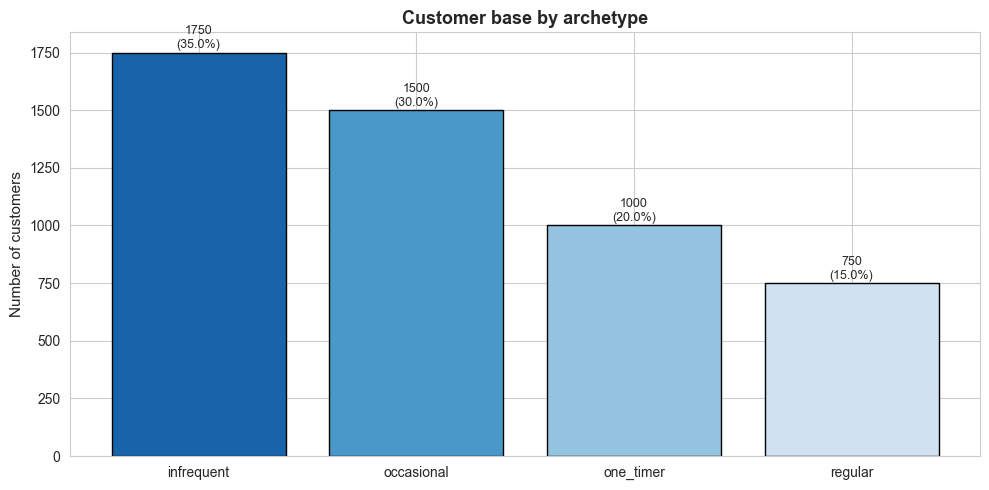


Archetype distribution:
infrequent    1750
occasional    1500
one_timer     1000
regular        750
Name: archetype, dtype: int64


In [6]:
arch_counts = customers['archetype'].value_counts()
arch_pct = (arch_counts / arch_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Blues_r', len(arch_counts))
bars = ax.bar(arch_counts.index, arch_counts.values, color=colors, edgecolor='black')
ax.set_title('Customer base by archetype')
ax.set_ylabel('Number of customers')
for bar, val, pct in zip(bars, arch_counts.values, arch_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({pct}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nArchetype distribution:")
print(arch_counts)

**Reading.** The archetype distribution follows a Pareto-like shape:
- **Regulars** (15%) are the smallest group but contribute the most orders
- **Occasionals** (30%) are the moderate-frequency middle
- **Infrequents** (35%) are the largest group but each contributes only 2-4 visits
- **One-timers** (20%) make a single visit

### 3.2 Behavioral dimensions overview

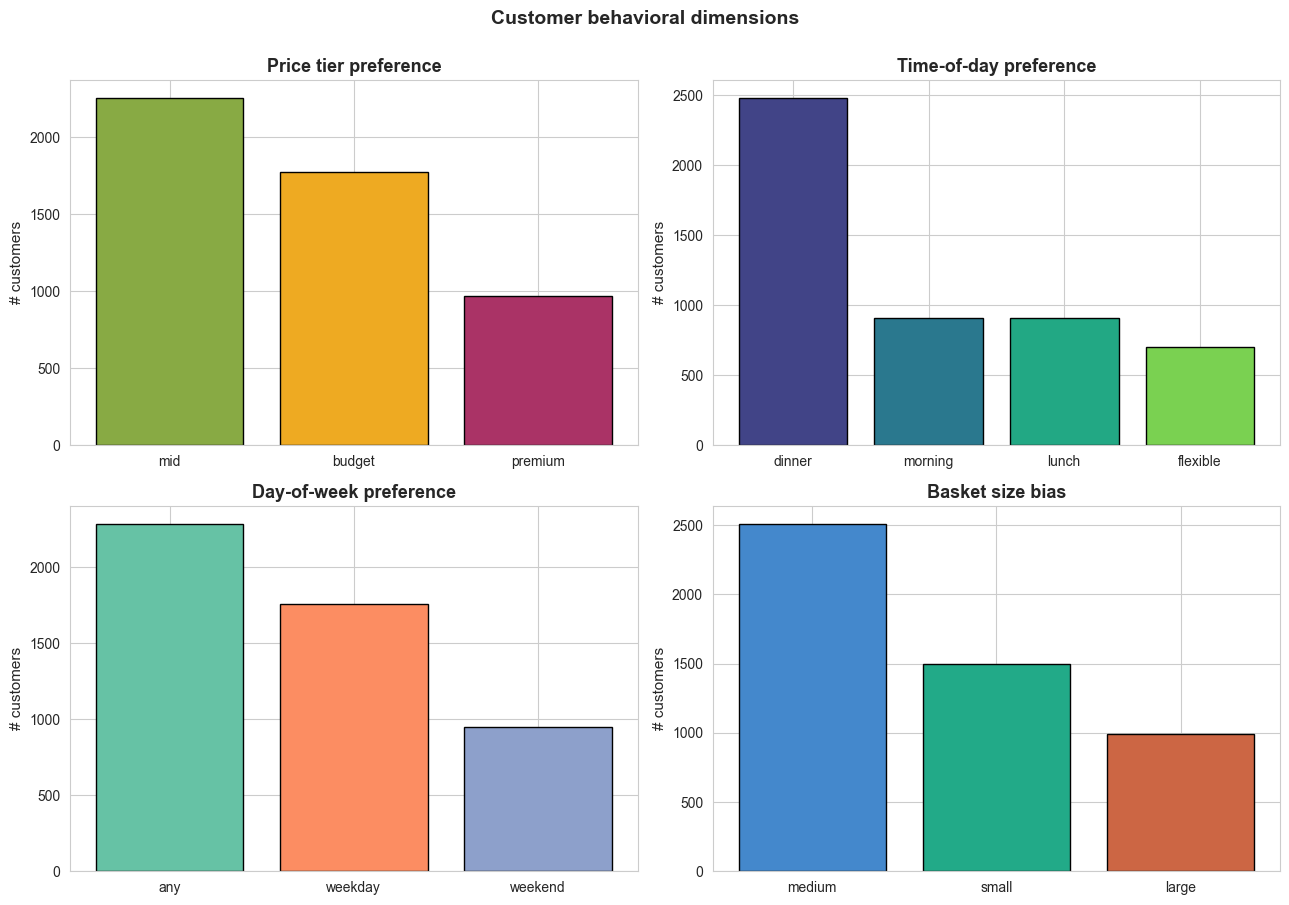

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Price tier
pt_counts = customers['price_tier'].value_counts()
colors_pt = ['#88aa44', '#eeaa22', '#aa3366']
axes[0, 0].bar(pt_counts.index, pt_counts.values, color=colors_pt, edgecolor='black')
axes[0, 0].set_title('Price tier preference')
axes[0, 0].set_ylabel('# customers')

# Time preference
tp_counts = customers['time_preference'].value_counts()
axes[0, 1].bar(tp_counts.index, tp_counts.values,
               color=sns.color_palette('viridis', len(tp_counts)), edgecolor='black')
axes[0, 1].set_title('Time-of-day preference')
axes[0, 1].set_ylabel('# customers')

# Day preference
dp_counts = customers['day_preference'].value_counts()
axes[1, 0].bar(dp_counts.index, dp_counts.values,
               color=sns.color_palette('Set2', len(dp_counts)), edgecolor='black')
axes[1, 0].set_title('Day-of-week preference')
axes[1, 0].set_ylabel('# customers')

# Basket size bias
bs_counts = customers['basket_size_bias'].value_counts()
axes[1, 1].bar(bs_counts.index, bs_counts.values,
               color=['#4488cc', '#22aa88', '#cc6644'], edgecolor='black')
axes[1, 1].set_title('Basket size bias')
axes[1, 1].set_ylabel('# customers')

plt.suptitle('Customer behavioral dimensions',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Reading.** Each dimension has multiple categories that customers are
assigned to independently. A single customer therefore has a unique
*combination* of (archetype, price_tier, time_pref, day_pref, basket_bias).
This combinatorial diversity is what makes meaningful clustering possible.

## 4. RFM Analysis

**RFM** (Recency, Frequency, Monetary) is the classic foundation of customer
segmentation:

- **Recency** = days since last visit (lower is better)
- **Frequency** = number of orders placed
- **Monetary** = total spend in dollars

We compute these by joining customers with the transactions file.

In [8]:
# Compute RFM per customer (only customers with at least one order)
ref_date = df['order_date'].max()

rfm = df[df['customer_id'] > 0].groupby('customer_id').agg(
    recency=('order_date', lambda x: (ref_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('line_total', 'sum'),
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

print(f"RFM computed for {len(rfm):,} active customers")
print("\nSummary statistics:")
rfm[['recency', 'frequency', 'monetary', 'avg_order_value']].describe().round(2)

RFM computed for 4,993 active customers

Summary statistics:


,recency,frequency,monetary,avg_order_value
count,4993.00,4993.00,4993.00,4993.00
mean,189.27,6.26,159.88,24.95
std,161.13,5.89,175.64,11.90
min,0.00,1.00,0.94,0.94
25%,36.00,2.00,40.00,16.60
50%,158.00,4.00,94.99,23.00
75%,318.00,9.00,215.16,31.08
max,546.00,28.00,1387.95,117.00


### 4.1 RFM distributions

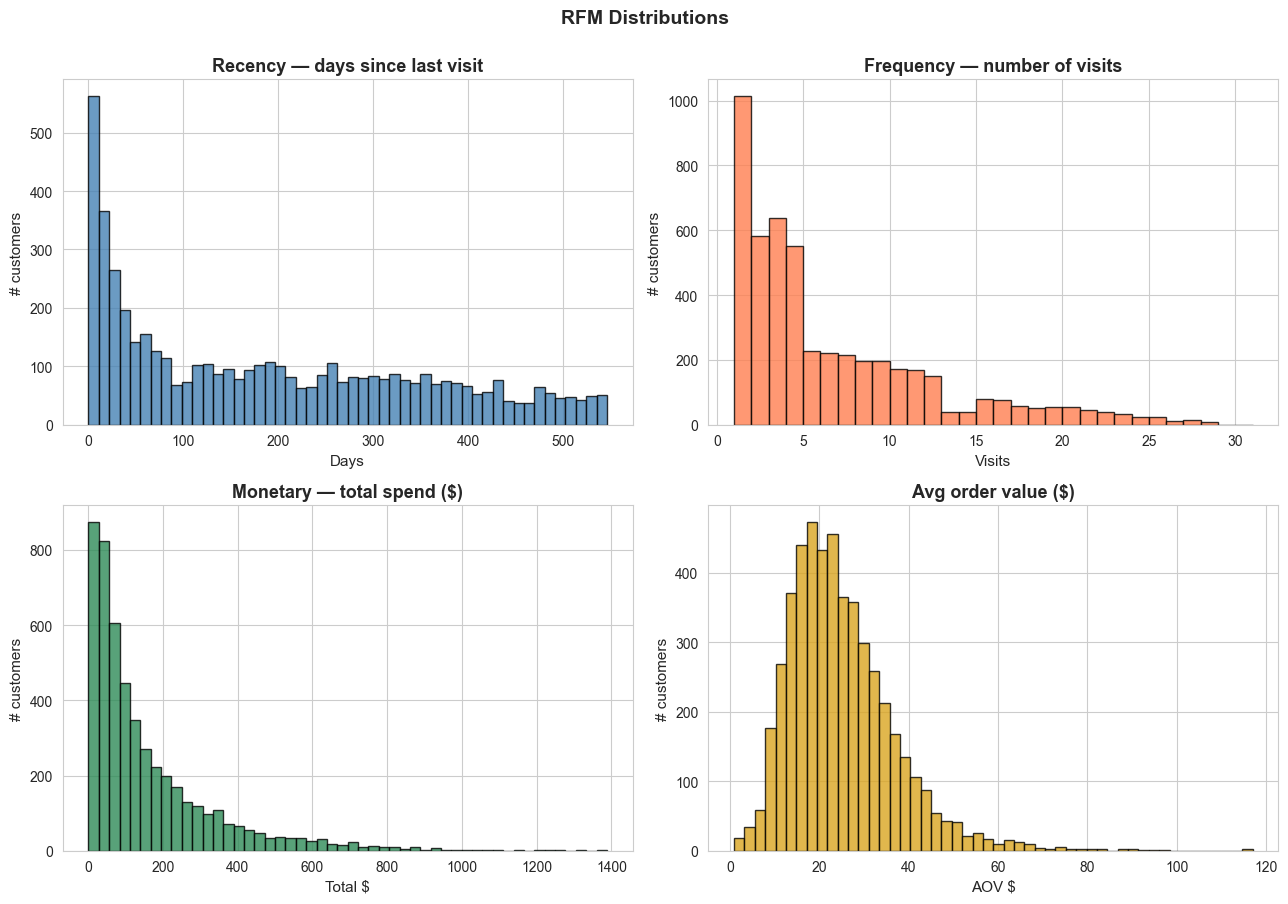

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(rfm['recency'], bins=50, color='steelblue',
                edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Recency — days since last visit')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('# customers')

axes[0, 1].hist(rfm['frequency'], bins=range(1, 32), color='coral',
                edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Frequency — number of visits')
axes[0, 1].set_xlabel('Visits')
axes[0, 1].set_ylabel('# customers')

axes[1, 0].hist(rfm['monetary'], bins=50, color='seagreen',
                edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Monetary — total spend ($)')
axes[1, 0].set_xlabel('Total $')
axes[1, 0].set_ylabel('# customers')

axes[1, 1].hist(rfm['avg_order_value'], bins=50, color='goldenrod',
                edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Avg order value ($)')
axes[1, 1].set_xlabel('AOV $')
axes[1, 1].set_ylabel('# customers')

plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Reading.**
- **Recency** is bimodal — many customers visited recently, but a long tail of
  customers haven't returned in weeks. This is the foundation of churn detection
- **Frequency** has a strong right skew — most customers visit a few times,
  rare ones visit 20+ times
- **Monetary** mirrors frequency but with more spread (high-value customers
  spend disproportionately)
- **AOV** is more concentrated — most customers spend $20-30 per visit

## 5. Pareto check — revenue concentration

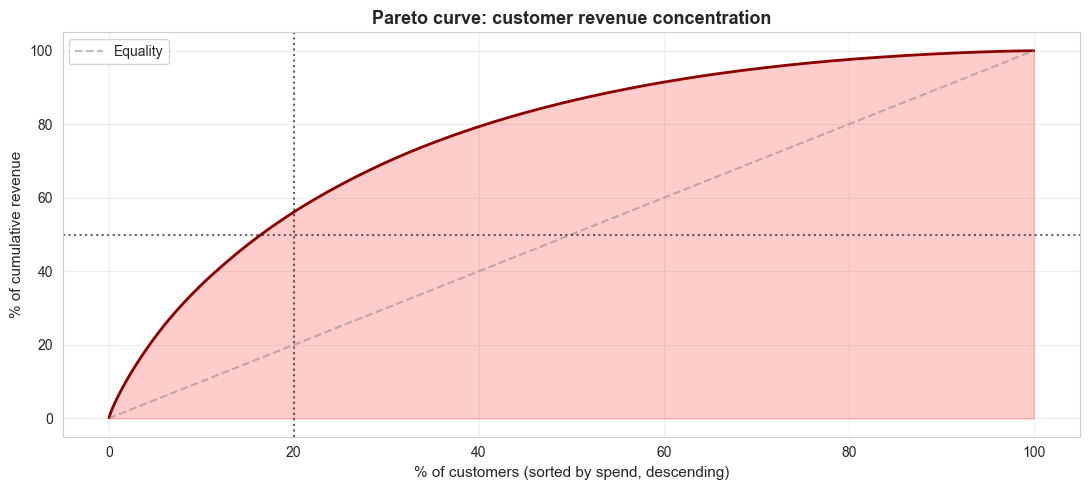


Revenue concentration:
  Top 5% of customers generate  22.0% of revenue
  Top 10% of customers generate 36.3% of revenue
  Top 20% of customers generate 56.1% of revenue


In [10]:
rfm_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cum_revenue'] = rfm_sorted['monetary'].cumsum() / rfm_sorted['monetary'].sum() * 100
rfm_sorted['cum_customers'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rfm_sorted['cum_customers'], rfm_sorted['cum_revenue'],
        color='darkred', linewidth=2)
ax.fill_between(rfm_sorted['cum_customers'], rfm_sorted['cum_revenue'],
                alpha=0.2, color='red')
ax.plot([0, 100], [0, 100], '--', color='gray', alpha=0.5, label='Equality')
ax.axvline(20, color='black', linestyle=':', alpha=0.6)
ax.axhline(50, color='black', linestyle=':', alpha=0.6)
ax.set_title('Pareto curve: customer revenue concentration')
ax.set_xlabel('% of customers (sorted by spend, descending)')
ax.set_ylabel('% of cumulative revenue')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compute key Pareto stats
top_20 = rfm_sorted.iloc[:int(len(rfm_sorted) * 0.20)]
top_10 = rfm_sorted.iloc[:int(len(rfm_sorted) * 0.10)]
top_5 = rfm_sorted.iloc[:int(len(rfm_sorted) * 0.05)]

print(f"\nRevenue concentration:")
print(f"  Top 5% of customers generate  {top_5['monetary'].sum() / rfm['monetary'].sum() * 100:.1f}% of revenue")
print(f"  Top 10% of customers generate {top_10['monetary'].sum() / rfm['monetary'].sum() * 100:.1f}% of revenue")
print(f"  Top 20% of customers generate {top_20['monetary'].sum() / rfm['monetary'].sum() * 100:.1f}% of revenue")

**Reading.** The curve bulging above the equality line shows real revenue
concentration. The "top 20% generate ~X% of revenue" rule justifies the
loyalty program, the targeted recommendations, and the Module 4 segmentation
work — the business case for treating high-value customers differently from
one-timers is data-backed.

## 6. Behavioral separation by dimension

How distinguishable are customers when we group them by their assigned
dimensions? This is the *clusterability* question — can K-Means or DBSCAN
recover these groupings without seeing the labels?

In [11]:
# Merge RFM with customer profiles
rfm_full = rfm.merge(customers, on='customer_id')

### 6.1 Frequency by archetype

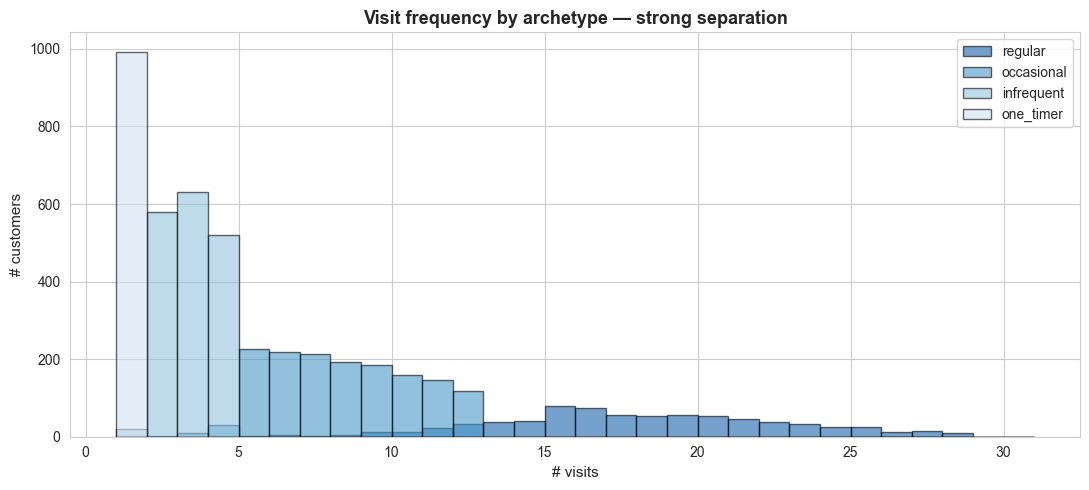


Mean frequency by archetype:
       regular: 17.6 visits  (n=750)
    occasional: 7.9 visits  (n=1500)
    infrequent: 2.9 visits  (n=1750)
     one_timer: 1.0 visits  (n=993)


In [12]:
archs = ['regular', 'occasional', 'infrequent', 'one_timer']
arch_colors = sns.color_palette('Blues_r', 4)

fig, ax = plt.subplots(figsize=(11, 5))
for i, arch in enumerate(archs):
    sub = rfm_full[rfm_full['archetype'] == arch]
    ax.hist(sub['frequency'], bins=range(1, 32), color=arch_colors[i],
            alpha=0.6, label=arch, edgecolor='black')
ax.set_title('Visit frequency by archetype — strong separation')
ax.set_xlabel('# visits')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean frequency by archetype:")
for arch in archs:
    sub = rfm_full[rfm_full['archetype'] == arch]
    print(f"  {arch:>12}: {sub['frequency'].mean():.1f} visits  (n={len(sub)})")

**Reading.** Archetype is the **strongest** segmentation dimension. The
histograms barely overlap — regulars cluster around 17-18 visits, occasionals
around 8, infrequents around 3, one-timers exactly at 1. K-Means with
frequency as a feature should recover this perfectly.

### 6.2 Spend by price tier

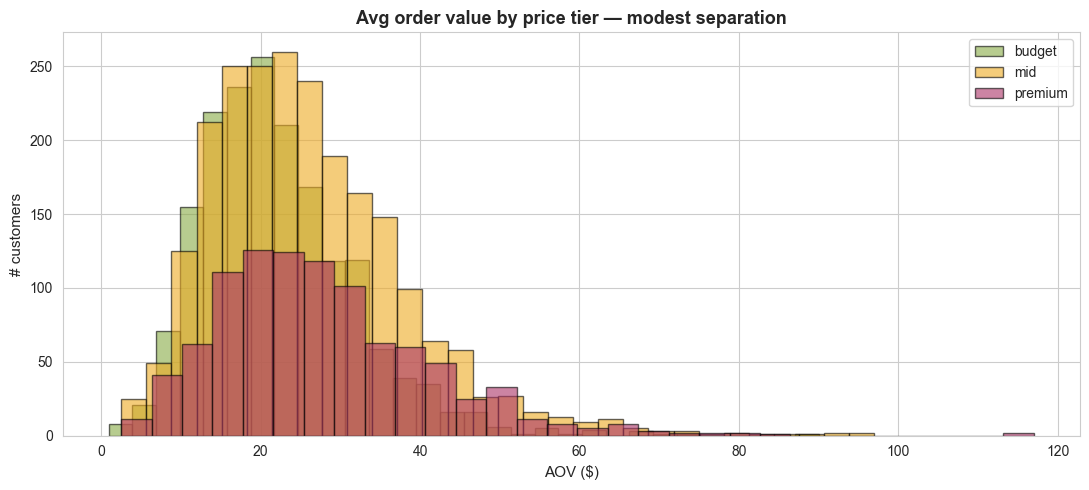


Mean AOV by price tier:
    budget: $22.23  (n=1770)
       mid: $25.84  (n=2255)
   premium: $27.84  (n=968)


In [13]:
tiers = ['budget', 'mid', 'premium']
tier_colors = ['#88aa44', '#eeaa22', '#aa3366']

fig, ax = plt.subplots(figsize=(11, 5))
for i, tier in enumerate(tiers):
    sub = rfm_full[rfm_full['price_tier'] == tier]
    ax.hist(sub['avg_order_value'], bins=30, color=tier_colors[i],
            alpha=0.6, label=tier, edgecolor='black')
ax.set_title('Avg order value by price tier — modest separation')
ax.set_xlabel('AOV ($)')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean AOV by price tier:")
for tier in tiers:
    sub = rfm_full[rfm_full['price_tier'] == tier]
    print(f"  {tier:>8}: ${sub['avg_order_value'].mean():.2f}  (n={len(sub)})")

**Reading.** Price tier separation is **weaker** than archetype. The
histograms overlap significantly — budget and premium customers both cluster
in the $20-30 AOV range with only a small mean shift. **This is a known
limitation:** in isolation, price_tier is not a strong feature. But combined
with other dimensions in a multi-dimensional clustering, it should still
contribute. Worth keeping an eye on for Module 4.

### 6.3 Spend by basket size bias

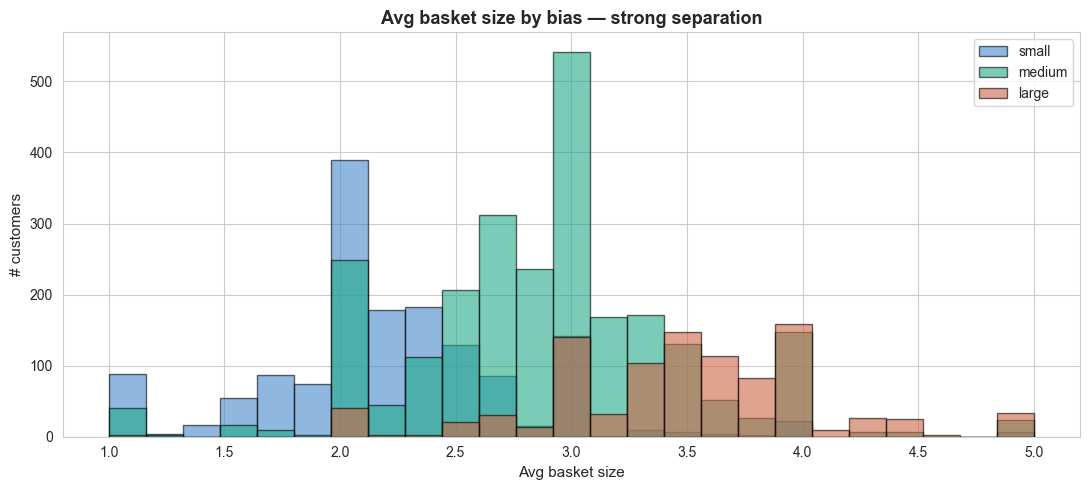


Mean basket size by bias:
     small: 2.21 items  (n=1498)
    medium: 2.88 items  (n=2506)
     large: 3.49 items  (n=989)


In [14]:
biases = ['small', 'medium', 'large']
bias_colors = ['#4488cc', '#22aa88', '#cc6644']

# Compute avg basket size per customer
cust_basket = df[df['customer_id'] > 0].groupby('customer_id').agg(
    n_orders=('order_id', 'nunique'),
    n_lines=('order_details_id', 'count'),
).reset_index()
cust_basket['avg_basket'] = cust_basket['n_lines'] / cust_basket['n_orders']
cust_full = cust_basket.merge(customers, on='customer_id')

fig, ax = plt.subplots(figsize=(11, 5))
for i, bias in enumerate(biases):
    sub = cust_full[cust_full['basket_size_bias'] == bias]
    ax.hist(sub['avg_basket'], bins=25, color=bias_colors[i],
            alpha=0.6, label=bias, edgecolor='black')
ax.set_title('Avg basket size by bias — strong separation')
ax.set_xlabel('Avg basket size')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean basket size by bias:")
for bias in biases:
    sub = cust_full[cust_full['basket_size_bias'] == bias]
    print(f"  {bias:>8}: {sub['avg_basket'].mean():.2f} items  (n={len(sub)})")

**Reading.** Basket bias is a **strong** dimension — clean separation
between small (~2.2), medium (~2.9), and large (~3.5) average basket sizes.
This will be a valuable feature for clustering.

## 7. Summary

### What's in the customer data
- **5,000 customer profiles** with 7 attributes each
- **Frequency archetypes:** regular / occasional / infrequent / one_timer
- **Behavioral dimensions:** price_tier, time_preference, day_preference, basket_size_bias
- **Section/category preferences** as comma-separated lists

### RFM characteristics
- **Recency:** bimodal distribution — recent visitors + lapsed customers
- **Frequency:** right-skewed, mean ~6 visits
- **Monetary:** strong concentration at the top (Pareto)
- **AOV:** centered around $20-30 with moderate spread

### Segmentation feature strength
| Dimension | Strength | Notes |
|---|---|---|
| **archetype** | Very strong | Cleanest signal — visits cleanly separate |
| **basket_size_bias** | Strong | 2.2 / 2.9 / 3.5 average — clearly distinguishable |
| **time_preference** | Strong | Aligned with section visit patterns |
| **day_preference** | Moderate | Detectable with weekday-share feature |
| **price_tier** | **Modest** | Small AOV separation — combine with other dimensions |

### Implications for Module 4 (Customer Segmentation)
- **Build features:** RFM + avg_basket + section_share + time_slot_share + category_share
- **Try multiple algorithms:** K-Means (k=4-8), DBSCAN, hierarchical
- **Evaluate against archetype labels** using ARI (Adjusted Rand Index) — expected 0.35-0.55
- **Combined-dimension clustering** should reach ARI 0.50-0.70 against joint labels

---

**Next:** open `03_anomalies_eda.ipynb` to explore the labeled anomaly data
and the suspicious cashier signal.
